# EDA

## Обзор данных

In [91]:
import pandas as pd
from sklearn.pipeline import make_pipeline


In [92]:
df = pd.read_csv('../data/train.csv')

In [93]:
df

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000,MORTGAGE,5.0,EDUCATION,D,25000,15.95,0.21,Y,10,0
58641,58641,28,28800,RENT,0.0,MEDICAL,C,10000,12.73,0.35,N,8,1
58642,58642,23,44000,RENT,7.0,EDUCATION,D,6800,16.00,0.15,N,2,1
58643,58643,22,30000,RENT,2.0,EDUCATION,A,5000,8.90,0.17,N,3,0


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [95]:
df.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


## Анализ целевой переменной

<Axes: xlabel='loan_status', ylabel='count'>

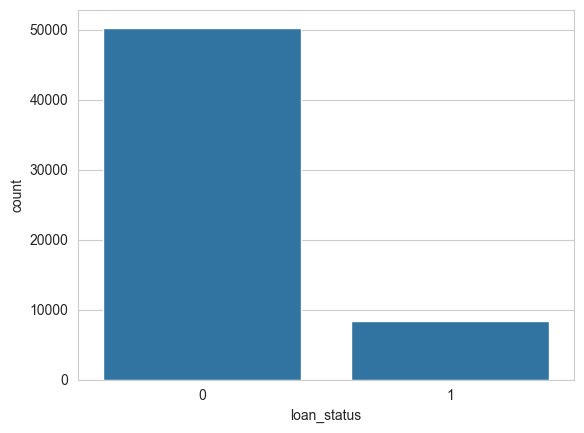

In [96]:
import seaborn as sns

sns.countplot(x=df['loan_status'])

In [97]:
df['loan_status'].value_counts(normalize=True) * 100

loan_status
0    85.761787
1    14.238213
Name: proportion, dtype: float64

Удалим столбец "id" из данных

In [98]:
df.drop(columns=['id'], inplace=True, axis=1)

## Отчет по данным

In [9]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Profiling report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 284.43it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Матрица корреляций

interval columns not set, guessing: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']


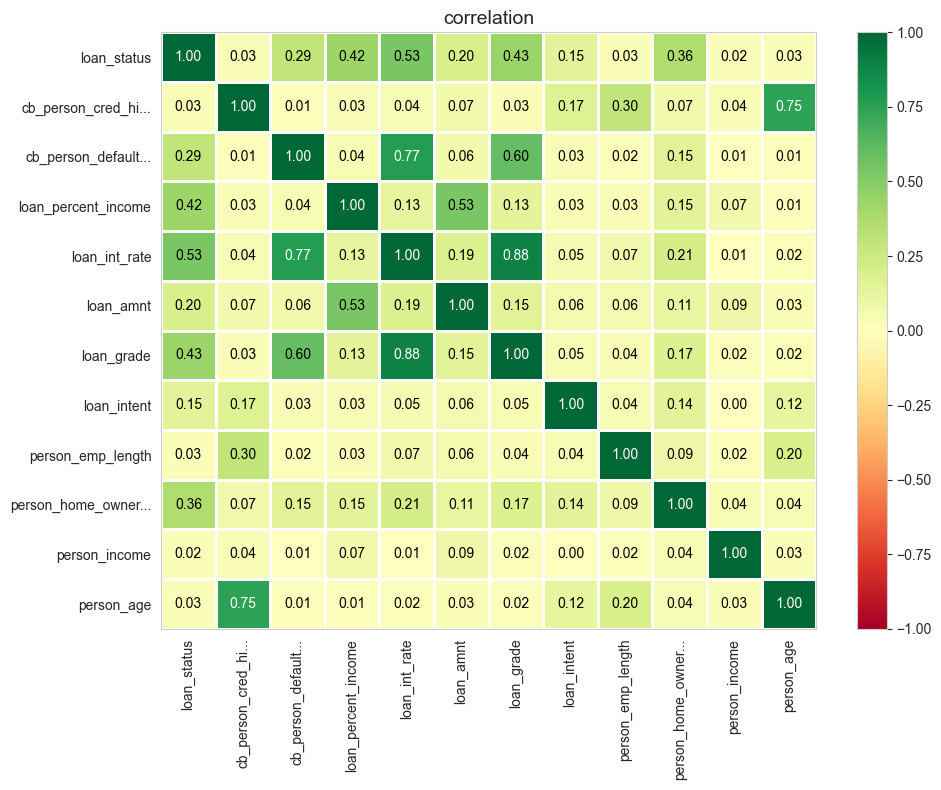

In [10]:
from phik.report import plot_correlation_matrix

corr_matrix = df.phik_matrix()
plot_correlation_matrix(corr_matrix.values, x_labels=corr_matrix.columns, y_labels=corr_matrix.index, figsize=(10, 8))

In [11]:
from sklearn.preprocessing import LabelEncoder

df['loan_grade'] = df['loan_grade'].map({'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6})
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

categorical_cols = df.select_dtypes(include=['object']).columns

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"   • {col}: {len(le.classes_)} категорий")

   • person_home_ownership: 4 категорий
   • loan_intent: 6 категорий


Корреляционная матрица числовых признаков от цели:

person_income                -0.169956
person_emp_length            -0.100428
loan_intent                  -0.048751
id                           -0.008138
cb_person_cred_hist_length   -0.003030
person_age                   -0.001130
loan_amnt                     0.144982
cb_person_default_on_file     0.186962
person_home_ownership         0.220167
loan_int_rate                 0.338948
loan_percent_income           0.378280
loan_grade                    0.385908
dtype: float64


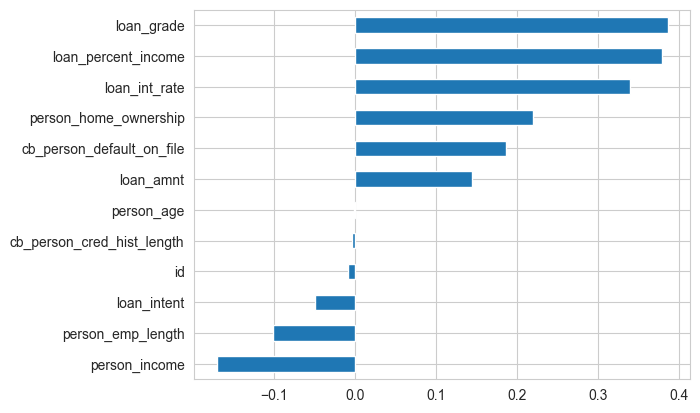

In [12]:
target_corrm = df.corrwith(df['loan_status']).drop(['loan_status']).sort_values()
target_corrm.plot(kind='barh')
print('Корреляционная матрица числовых признаков от цели:\n')
print(target_corrm)

# Построение классов для дальнейшей работы

## Класс для быстрого формирования предобработанного датасета

In [22]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from typing import Dict, List, Optional


class LoanDataPreprocessor:
    def __init__(
            self,
            drop_columns: Optional[List[str]] = None,
            manual_mappings: Optional[Dict] = None,
    ):
        self.drop_columns = drop_columns or ['loan_int_rate', 'person_age', 'id']
        self.manual_mappings = manual_mappings or {
            'loan_grade': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6},
            'cb_person_default_on_file': {'N': 0, 'Y': 1}
        }

        self.label_encoders: Dict[str, LabelEncoder] = {}
        self.categorical_cols_: Optional[List[str]] = None
        self.is_fitted = False

    def _drop(self, df: pd.DataFrame) -> pd.DataFrame:
        cols_to_drop = [c for c in self.drop_columns if c in df.columns]
        return df.drop(columns=cols_to_drop) if cols_to_drop else df

    def _apply_manual_mappings(self, df: pd.DataFrame, for_train: bool) -> pd.DataFrame:
        df = df.copy()
        for col, mapping in self.manual_mappings.items():
            if col in df.columns:
                df[col] = df[col].map(mapping)
                if not for_train:
                    df[col] = df[col].where(df[col].notna(), -1)
        return df

    def preprocess_train(self, df: pd.DataFrame, verbose: bool = False) -> pd.DataFrame:
        df = df.copy()

        df['income_loan_diff'] = df['person_income'] - df['loan_amnt']
        df['person_income'] = np.log1p(df['person_income'])
        df['loan_amnt'] = np.log1p(df['loan_amnt'])

        df = self._drop(df)
        df = self._apply_manual_mappings(df, for_train=True)

        self.categorical_cols_ = list(df.select_dtypes(include=['object']).columns)

        # self.label_encoders = {}
        # for col in self.categorical_cols_:
        #     le = LabelEncoder()
        #     df[col] = le.fit_transform(df[col].astype(str))
        #     self.label_encoders[col] = le
        #     if verbose:
        #         print(f"• {col}: classes={len(le.classes_)}")

        train_data = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

        self.is_fitted = True
        return train_data

    def preprocess_test(self, df: pd.DataFrame, verbose: bool = False) -> pd.DataFrame:
        if not self.is_fitted:
            raise ValueError("Сначала обучи препроцессор на train: preprocess_train()")

        df['income_loan_diff'] = df['person_income'] - df['loan_amnt']
        df['person_income'] = np.log1p(df['person_income'])
        df['loan_amnt'] = np.log1p(df['loan_amnt'])

        df = df.copy()
        df = self._drop(df)
        df = self._apply_manual_mappings(df, for_train=False)

        data = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

        return data


## Класс обертка для пайплайна

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin

class PreprocessorWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, preprocessor: LoanDataPreprocessor):
        self.preprocessor = preprocessor

    def fit(self, X, y=None):
        self.preprocessor.preprocess_train(X)
        return self

    def transform(self, X):
        return self.preprocessor.preprocess_test(X)


In [24]:
preprocessor = LoanDataPreprocessor(
    drop_columns=['loan_int_rate', 'person_age', 'id']
)

## Класс для визуализации

In [4]:
import plotly.graph_objects as go
import plotly.express as px
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
# from sklearn.model_selection import cross_val_predict, StratifiedKFold
import os

class ModelVisualizer:
    def __init__(self, model, X: np.ndarray, y: np.ndarray, name):
        self.model = model
        self.X = X
        self.y = y
        self.name = name

    def _get_predictions(self):
        return self.model.predict_proba(self.X)[:, 1]

    def save_figure(self, fig: go.Figure, filename: str, file_format: str = 'png') -> None:
        if not os.path.exists(f'visualizations/{self.name}'):
            os.makedirs(f'visualizations/{self.name}')

        file_path = f'visualizations/{self.name}/{filename}.{file_format}'
        fig.write_image(file_path)
        print(f"График сохранен в {file_path}")

    def plot_roc_curve(self) -> None:
        y_pred_proba = self._get_predictions()
        fpr, tpr, thresholds = roc_curve(self.y, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        fig = go.Figure()

        fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC curve (AUC = {roc_auc:.2f})'))
        fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random', line={'dash': 'dash'}))

        fig.update_layout(
            title="ROC Curve",
            xaxis_title="False Positive Rate",
            yaxis_title="True Positive Rate",
            showlegend=True
        )

        self.save_figure(fig, 'roc_curve')

        fig.show()

    def plot_precision_recall_curve(self) -> go.Figure:
        y_pred_proba = self._get_predictions()
        precision, recall, _ = precision_recall_curve(self.y, y_pred_proba)

        fig = go.Figure()

        fig.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name="Precision-Recall curve"))

        fig.update_layout(
            title="Precision-Recall Curve",
            xaxis_title="Recall",
            yaxis_title="Precision",
            showlegend=True
        )

        self.save_figure(fig, 'precision-recall_curve')

        return fig

    def plot_confusion_matrix(self) -> go.Figure:
        y_pred = self.model.predict(self.X)
        cm = confusion_matrix(self.y, y_pred)

        cm_df = pd.DataFrame(cm, index=['True Class 0', 'True Class 1'], columns=['Predicted 0', 'Predicted 1'])

        fig = px.imshow(cm_df, text_auto=True, color_continuous_scale='Blues', title='Confusion Matrix')

        fig.update_layout(
            xaxis_title="Predicted Labels",
            yaxis_title="True Labels",
            showlegend=False
        )

        self.save_figure(fig, 'confusion_matrix')

        return fig

    def plot_metrics_comparison(self) -> go.Figure:
        y_pred_proba = self._get_predictions()

        roc_auc = roc_auc_score(self.y, y_pred_proba)
        pr_auc = average_precision_score(self.y, y_pred_proba)
        precision = precision_score(self.y, (y_pred_proba > 0.5))
        recall = recall_score(self.y, (y_pred_proba > 0.5))
        f1 = f1_score(self.y, (y_pred_proba > 0.5))

        metrics = ['ROC AUC', 'PR AUC', 'Precision', 'Recall', 'F1']
        values = [roc_auc, pr_auc, precision, recall, f1]

        fig = go.Figure(
            go.Bar(
                x=metrics,
                y=values,
                marker=dict(color='royalblue'),
                text=[f"{v:.4f}" for v in values],
                textposition='auto',
                textfont=dict(size=12)
            )
        )

        fig.update_layout(
            title="Model Performance Metrics",
            xaxis_title="Metrics",
            yaxis_title="Value",
            yaxis=dict(range=[0, 1]),
            showlegend=False
        )

        self.save_figure(fig, 'metrics_comparison')

        return fig

    def plot_feature_importance(self) -> None:
        if hasattr(self.model, "named_steps"):
            estimator = self.model.named_steps.get("classifier", self.model)
        else:
            estimator = self.model

        if hasattr(estimator, "feature_importances_"):
            importances = estimator.feature_importances_
            title = "Feature Importance"
        elif hasattr(estimator, "coef_"):
            importances = np.abs(estimator.coef_).ravel()
            title = "Feature Importance (absolute coefficients)"
        else:
            print("Модель не поддерживает отображение важности признаков.")
            return

        importances = np.asarray(importances).ravel()

        feature_names = None
        if hasattr(self.model, "named_steps") and "preprocessor" in self.model.named_steps:
            X_trans = self.model.named_steps["preprocessor"].transform(self.X.iloc[:5] if hasattr(self.X, "iloc") else self.X[:5])
            if hasattr(X_trans, "columns"):
                feature_names = list(X_trans.columns)

        if feature_names is None:
            feature_names = [f"Feature {i}" for i in range(len(importances))]

        n = min(len(feature_names), len(importances))
        feature_names = feature_names[:n]
        importances = importances[:n]

        order = np.argsort(importances)
        feature_names = [feature_names[i] for i in order]
        importances = importances[order]

        fig = go.Figure()
        fig.add_trace(go.Bar(x=importances, y=feature_names, orientation="h"))
        fig.update_layout(title=title, xaxis_title="Importance", yaxis_title="Feature", showlegend=False)

        self.save_figure(fig, "feature_importance")
        fig.show()




# Класс для фильтрации выбросов

In [5]:
from dataclasses import dataclass, field
from typing import Callable, List, Dict, Any
import pandas as pd

Rule = Callable[[pd.DataFrame], pd.Series]

@dataclass
class RowFilter:
    rules: List[Rule] = field(default_factory=list)

    def add_rule(self, rule: Rule) -> "RowFilter":
        self.rules.append(rule)
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df2 = df.copy()
        if not self.rules:
            return df2

        mask = pd.Series(True, index=df2.index)
        for rule in self.rules:
            mask &= rule(df2)

        return df2.loc[mask].copy()

    def summary(self, df_before: pd.DataFrame, df_after: pd.DataFrame) -> Dict[str, Any]:
        return {
            "before_rows": len(df_before),
            "after_rows": len(df_after),
            "removed_rows": len(df_before) - len(df_after),
        }

In [6]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/train.csv")

f = RowFilter() \
    .add_rule(lambda d: d["person_age"] <= 122) \
    .add_rule(lambda d: d["person_emp_length"] <= d['person_age'] - 16)

df = f.transform(df)

In [7]:
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [8]:
preprocessor.preprocess_train(df)

,person_income,person_emp_length,loan_grade,loan_amnt,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status,income_loan_diff,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,35000,0.0,1,6000,0.17,0,14,0,29000,False,False,True,True,False,False,False,False
1,56000,6.0,2,4000,0.07,0,2,0,52000,False,True,False,False,False,True,False,False
2,28800,8.0,0,6000,0.21,0,10,0,22800,False,True,False,False,False,False,True,False
3,70000,14.0,1,12000,0.17,0,5,0,58000,False,False,True,False,False,False,False,True
4,60000,2.0,0,6000,0.10,0,3,0,54000,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,120000,5.0,3,25000,0.21,1,10,0,95000,False,False,False,True,False,False,False,False
58641,28800,0.0,2,10000,0.35,0,8,1,18800,False,False,True,False,False,True,False,False
58642,44000,7.0,3,6800,0.15,0,2,1,37200,False,False,True,True,False,False,False,False
58643,30000,2.0,0,5000,0.17,0,3,0,25000,False,False,True,True,False,False,False,False


# Базовый класс модели

In [9]:
from abc import ABC, abstractmethod
from typing import Dict, List, Optional, Union, Any
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, \
    roc_auc_score, average_precision_score, accuracy_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns


class BaseModel(ABC):
    def __init__(self, preprocessor, random_state: int = 42):
        self.random_state = random_state
        self.model = None
        self.best_params_ = None
        self.best_score_ = None
        self.preprocessor = preprocessor

    @abstractmethod
    def create_pipeline(self) -> Pipeline:
        pass

    @abstractmethod
    def get_param_grid(self) -> List[Dict]:
        pass

    def train(self, X_train: np.ndarray, y_train: np.ndarray, cv: int = 3,
              scoring: str = 'roc_auc', n_jobs: int = -1) -> None:

        pipeline = self.create_pipeline()
        param_grid = self.get_param_grid()

        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=self.random_state)

        rs = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grid,
            n_iter=50,
            scoring="roc_auc",
            cv=skf,
            n_jobs=-1,
            random_state=self.random_state,
            verbose=1
        )

        rs.fit(X_train, y_train)

        self.model = rs.best_estimator_
        self.best_params_ = rs.best_params_
        self.best_score_ = rs.best_score_

        print(f'Лучшие параметры: {self.best_params_}')
        print(f'Лучшее качество на кросс-валидации: {self.best_score_:.4f}')

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")
        return self.model.predict(X)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")
        return self.model.predict_proba(X)

# Логистическая регрессия

In [213]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform, uniform

class LogisticRegressionModel(BaseModel):

    def __init__(self, preprocessor, random_state: int = 42,
                 class_weight_options: List = None):
        super().__init__(preprocessor, random_state)
        self.class_weight_options = class_weight_options or ['balanced', None]

    def create_pipeline(self) -> Pipeline:

        return Pipeline(steps = [
            ('preprocessor', PreprocessorWrapper(LoanDataPreprocessor(
                drop_columns=['loan_int_rate', 'person_age', 'id']
            ))),
            ('scaler', StandardScaler()),
            ('logisticregression', LogisticRegression(
                random_state=self.random_state,
                n_jobs=-1,
                max_iter=1000
            )),
        ])

    def get_param_grid(self) -> List[Dict]:
        return [
            {
                "logisticregression__penalty": ["l1"],
                "logisticregression__solver": ["saga"],
                "logisticregression__C": loguniform(1e-4, 1e2),
                "logisticregression__class_weight": ["balanced", None],
            },
            {
                "logisticregression__penalty": ["l2"],
                "logisticregression__solver": ["lbfgs", "saga", "newton-cg"],
                "logisticregression__C": loguniform(1e-4, 1e2),
                "logisticregression__class_weight": ["balanced", None],
            },
            {
                "logisticregression__penalty": ["elasticnet"],
                "logisticregression__solver": ["saga"],
                "logisticregression__C": loguniform(1e-4, 1e2),
                "logisticregression__l1_ratio": uniform(0.0, 1.0),
                "logisticregression__class_weight": ["balanced", None],
            }
        ]

    def plot_threshold_analysis(self, X_test: np.ndarray, y_test: np.ndarray):
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")

        y_proba_pred = self.model.predict_proba(X_test)[:, 1]

        thresholds = np.arange(0.1, 1, 0.05)
        recall_scores = []
        precision_scores = []
        f1_scores = []

        for threshold in thresholds:
            y_pred = (y_proba_pred > threshold).astype(int)
            recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
            precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
            f1_scores.append(f1_score(y_test, y_pred, zero_division=0))

        plt.figure(figsize=(12, 6))
        plt.plot(thresholds, recall_scores, label='Recall', marker='o')
        plt.plot(thresholds, precision_scores, label='Precision', marker='s')
        plt.plot(thresholds, f1_scores, label='F1-score', marker='^')

        plt.title('Зависимость метрик от порога вероятности')
        plt.xlabel('Порог вероятности')
        plt.ylabel('Метрика')
        plt.xticks(thresholds, rotation=45)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [214]:
lr_model = LogisticRegressionModel(preprocessor)

In [215]:
lr_model.train(X_train, y_train, cv=5)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\rusla\DataspellProjects\cred\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

C:\Users\rusla\DataspellProjects\cred\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.



Лучшие параметры: {'logisticregression__C': np.float64(0.008935110590331868), 'logisticregression__class_weight': 'balanced', 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'saga'}
Лучшее качество на кросс-валидации: 0.8946


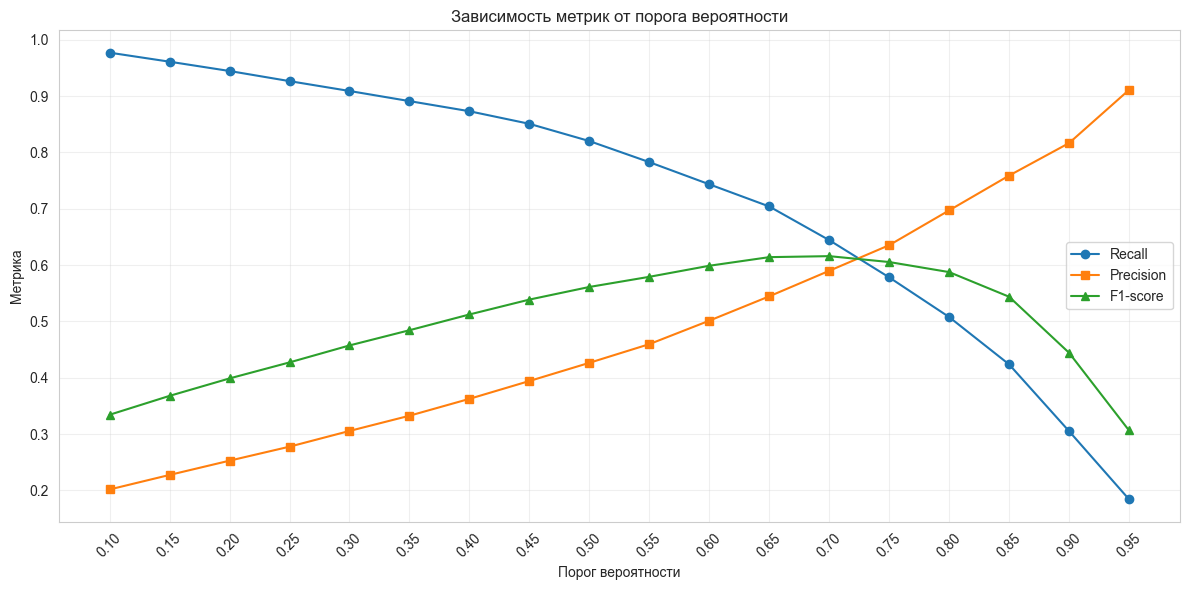

In [217]:
lr_model.plot_threshold_analysis(X_test, y_test)

In [218]:
lr_visualizer = ModelVisualizer(lr_model.model, X_test, y_test, "logistic_regression/03")

In [219]:
lr_visualizer.plot_roc_curve()

График сохранен в visualizations/logistic_regression/03/roc_curve.png


In [23]:
lr_visualizer.plot_precision_recall_curve()

График сохранен в visualizations/logistic_regression/precision-recall_curve.png


In [220]:
lr_visualizer.plot_metrics_comparison()

График сохранен в visualizations/logistic_regression/03/metrics_comparison.png


In [221]:
lr_visualizer.plot_confusion_matrix()

График сохранен в visualizations/logistic_regression/03/confusion_matrix.png


# Модель решающего дерева

In [224]:
from sklearn.tree import DecisionTreeClassifier


class DecisionTreeModel(BaseModel):

    def __init__(self, preprocessor, random_state: int = 42,
                 class_weight_options: List = None,
                 max_depth_range: List = None,
                 min_samples_split_range: List = None,
                 min_samples_leaf_range: List = None,
                 criterion_options: List = None):
        super().__init__(preprocessor, random_state)

        self.class_weight_options = class_weight_options or ['balanced', None]
        self.max_depth_range = max_depth_range or [None, 5, 10, 15, 20, 30]
        self.min_samples_split_range = min_samples_split_range or [2, 5, 10, 20]
        self.min_samples_leaf_range = min_samples_leaf_range or [1, 2, 4, 8]
        self.criterion_options = criterion_options or ['gini', 'entropy']

    def create_pipeline(self) -> Pipeline:
        return Pipeline([
            ('preprocessor', PreprocessorWrapper(self.preprocessor)),
            ('classifier', DecisionTreeClassifier(random_state=self.random_state))
        ])

    def get_param_grid(self) -> List[Dict]:
        return [{
            'classifier__max_depth': range(1, 6),
            'classifier__min_samples_split': [2, 5, 10, 15, 20],
            'classifier__min_samples_leaf': [1, 3, 5, 10, 15],
            'classifier__max_features': [None, 'sqrt', 'log2', 0.3, 0.5],
            'classifier__criterion': ['gini', 'entropy'],
            'classifier__class_weight': [None, 'balanced']
        }]


    def plot_tree_structure(self, columns) -> None:
        from sklearn import tree

        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")

        tree_model = self.model.named_steps['classifier']

        plt.figure(figsize=(15, 10))
        tree.plot_tree(
            tree_model,
            feature_names=columns,
            class_names=["0 - не одобрено", "1 - одобрено"],
            filled=True,
        )
        plt.show()

In [225]:
dt_model = DecisionTreeModel(preprocessor)
dt_model.train(X_train, y_train, cv=5)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры: {'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 15, 'classifier__max_features': None, 'classifier__max_depth': 5, 'classifier__criterion': 'entropy', 'classifier__class_weight': 'balanced'}
Лучшее качество на кросс-валидации: 0.9074


In [226]:
dt_visualizer = ModelVisualizer(dt_model.model, X_test, y_test, "decision_tree/03")

In [227]:
dt_visualizer.plot_roc_curve()

График сохранен в visualizations/decision_tree/03/roc_curve.png


In [228]:
dt_visualizer.plot_confusion_matrix()

График сохранен в visualizations/decision_tree/03/confusion_matrix.png


In [229]:
dt_visualizer.plot_metrics_comparison()

График сохранен в visualizations/decision_tree/03/metrics_comparison.png


In [230]:
dt_visualizer.plot_feature_importance()

График сохранен в visualizations/decision_tree/03/feature_importance.png


# XGBoost

In [25]:
from xgboost import XGBClassifier

class XGBoostModel(BaseModel):

    def __init__(self, preprocessor, random_state: int = 42):
        super().__init__(preprocessor, random_state)

    def create_pipeline(self) -> Pipeline:
        return Pipeline([
            ('preprocessor', PreprocessorWrapper(self.preprocessor)),
            ('classifier', XGBClassifier(random_state=self.random_state, use_label_encoder=False, eval_metric='logloss'))
        ])

    def get_param_grid(self) -> List[Dict]:
        return [{
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [3, 5, 7, 9],
            'classifier__learning_rate': [0.01, 0.1, 0.3],
            'classifier__subsample': [0.8, 0.9, 1.0],
            'classifier__colsample_bytree': [0.8, 0.9, 1.0]
        }]

In [26]:
preprocessor = LoanDataPreprocessor(drop_columns=['id', 'person_age', 'loan_int_rate'])
preprocessor.preprocess_train(X)

,person_income,person_emp_length,loan_grade,loan_amnt,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_loan_diff,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,35000,0.0,1,6000,0.17,0,14,29000,False,False,True,True,False,False,False,False
1,56000,6.0,2,4000,0.07,0,2,52000,False,True,False,False,False,True,False,False
2,28800,8.0,0,6000,0.21,0,10,22800,False,True,False,False,False,False,True,False
3,70000,14.0,1,12000,0.17,0,5,58000,False,False,True,False,False,False,False,True
4,60000,2.0,0,6000,0.10,0,3,54000,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,120000,5.0,3,25000,0.21,1,10,95000,False,False,False,True,False,False,False,False
58641,28800,0.0,2,10000,0.35,0,8,18800,False,False,True,False,False,True,False,False
58642,44000,7.0,3,6800,0.15,0,2,37200,False,False,True,True,False,False,False,False
58643,30000,2.0,0,5000,0.17,0,3,25000,False,False,True,True,False,False,False,False


In [27]:
xgboost_model = XGBoostModel(preprocessor)
xgboost_model.train(X_train, y_train, cv=5)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры: {'classifier__subsample': 1.0, 'classifier__n_estimators': 300, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.3, 'classifier__colsample_bytree': 1.0}
Лучшее качество на кросс-валидации: 0.9538


C:\Users\rusla\DataspellProjects\cred\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:27:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [29]:
xgb_visualizer = ModelVisualizer(xgboost_model.model, X_test, y_test, "xgboost/04")

In [30]:
xgb_visualizer.plot_confusion_matrix()

График сохранен в visualizations/xgboost/04/confusion_matrix.png


In [31]:
xgb_visualizer.plot_roc_curve()

График сохранен в visualizations/xgboost/04/roc_curve.png


In [32]:
xgb_visualizer.plot_metrics_comparison()

График сохранен в visualizations/xgboost/04/metrics_comparison.png


In [42]:
xgb_visualizer.plot_feature_importance()

C:\Users\rusla\AppData\Local\Temp\ipykernel_28608\3543730014.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



График сохранен в visualizations/xgboost/04/feature_importance.png


In [44]:
booster = xgboost_model.model.named_steps['classifier'].get_booster()
importance = booster.get_score(importance_type='gain')

import pandas as pd
fi = (
    pd.DataFrame(importance.items(), columns=['feature', 'gain'])
    .sort_values('gain', ascending=False)
)

print(fi.head(20))

                        feature       gain
10   person_home_ownership_RENT  73.586159
2                    loan_grade  67.819290
4           loan_percent_income  67.357758
9     person_home_ownership_OWN  32.092297
13          loan_intent_MEDICAL  24.925859
12  loan_intent_HOMEIMPROVEMENT  19.049400
15          loan_intent_VENTURE  13.575287
0                 person_income  12.296001
1             person_emp_length   9.509962
14         loan_intent_PERSONAL   9.079627
11        loan_intent_EDUCATION   8.862556
7              income_loan_diff   3.500465
3                     loan_amnt   2.867400
8   person_home_ownership_OTHER   2.797984
6    cb_person_cred_hist_length   2.661215
5     cb_person_default_on_file   2.415740


In [45]:
preprocessor = LoanDataPreprocessor(drop_columns=['id', 'loan_int_rate', 'person_age', 'cb_person_default_on_file', 'cb_person_cred_hist_length'])

In [46]:
xgboost_model = XGBoostModel(preprocessor)
xgboost_model.train(X_train, y_train, cv=5)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\rusla\DataspellProjects\cred\venv\Lib\site-packages\xgboost\training.py:199: UserWarning:

[13:38:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.




Лучшие параметры: {'classifier__subsample': 1.0, 'classifier__n_estimators': 300, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.3, 'classifier__colsample_bytree': 1.0}
Лучшее качество на кросс-валидации: 0.9542


In [47]:
xgb_visualizer = ModelVisualizer(xgboost_model.model, X_test, y_test, "xgboost/05/with_deleted_features")

03 - до добавления нового признака
04 - после добавления нового признака
05 - после удаления маловажных фич

In [48]:
xgb_visualizer.plot_metrics_comparison()

График сохранен в visualizations/xgboost/05/with_deleted_features/metrics_comparison.png


In [28]:
Xt = xgboost_model.model.named_steps['preprocessor'].transform(X_train.iloc[:5])
print("RAW:", X_train.shape, "TRANSFORMED:", Xt.shape)
print("Есть income_loan_diff после preprocess?", "income_loan_diff" in Xt.columns)

RAW: (43246, 13) TRANSFORMED: (5, 12)
Есть income_loan_diff после preprocess? True


C:\Users\rusla\AppData\Local\Temp\ipykernel_28608\3543730014.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['income_loan_diff'] = df['person_income'] - df['loan_amnt']


# Random Forest

In [240]:
from sklearn.ensemble import RandomForestClassifier

class RandomForestModel(BaseModel):

    def __init__(self, preprocessor, random_state: int = 42):
        super().__init__(preprocessor, random_state)

    def create_pipeline(self) -> Pipeline:
        return Pipeline([
            ('preprocessor', PreprocessorWrapper(self.preprocessor)),
            ('classifier', RandomForestClassifier(random_state=self.random_state))
        ])

    def get_param_grid(self) -> List[Dict]:
        return [{
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': range(1, 6),
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__class_weight': ['balanced', None]
        }]



In [241]:
rf_model = RandomForestModel(preprocessor)

In [242]:
rf_model.train(X_train, y_train, cv=5)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 5, 'classifier__class_weight': 'balanced'}
Лучшее качество на кросс-валидации: 0.9200


In [243]:
rf_visualizer = ModelVisualizer(rf_model.model, X_test, y_test, "random_forest/03")

In [244]:
rf_visualizer.plot_confusion_matrix()

График сохранен в visualizations/random_forest/03/confusion_matrix.png


In [245]:
rf_visualizer.plot_roc_curve()

График сохранен в visualizations/random_forest/03/roc_curve.png


In [246]:
rf_visualizer.plot_metrics_comparison()

График сохранен в visualizations/random_forest/03/metrics_comparison.png


In [247]:
rf_visualizer.plot_feature_importance()

График сохранен в visualizations/random_forest/03/feature_importance.png


In [248]:
print(rf_model.model.named_steps['preprocessor'].preprocessor.drop_columns)

['loan_int_rate', 'person_age', 'id']


In [249]:
Xt = rf_model.model.named_steps['preprocessor'].transform(X_train.iloc[:5])
print("RAW:", X_train.shape, "TRANSFORMED:", Xt.shape)
print("Есть loan_int_rate после preprocess?", "loan_int_rate" in Xt.columns)

RAW: (43246, 12) TRANSFORMED: (5, 11)
Есть loan_int_rate после preprocess? False


# LightGBM

In [250]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

lgbm_silent_params = {
    "classifier__verbosity": -1,
    "classifier__verbose": -1,
}

warnings.filterwarnings("ignore", message=".*LightGBM.*")
warnings.filterwarnings("ignore", message=".*No further splits with positive gain.*")

In [251]:
from lightgbm import LGBMClassifier

class LightGBMModel(BaseModel):

    def __init__(self, preprocessor, random_state: int = 42):
        super().__init__(preprocessor, random_state)

    def create_pipeline(self) -> Pipeline:
        return Pipeline([
            ('preprocessor', PreprocessorWrapper(self.preprocessor)),
            ('classifier', LGBMClassifier(random_state=self.random_state))
        ])

    def get_param_grid(self) -> List[Dict]:
        return [{
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': range(1, 6),
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__class_weight': ['balanced', None],

            "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],

            "classifier__verbosity": [-1],
            "classifier__verbose": [-1],
        }]



In [252]:
lgbm_model = LightGBMModel(preprocessor)
lgbm_model.train(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Лучшие параметры: {'classifier__verbosity': -1, 'classifier__verbose': -1, 'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1, 'classifier__class_weight': None}
Лучшее качество на кросс-валидации: 0.9522


In [253]:
lgbm_visualizer = ModelVisualizer(lgbm_model.model, X_test, y_test, "lgbm/03")

In [254]:
lgbm_visualizer.plot_confusion_matrix()

График сохранен в visualizations/lgbm/03/confusion_matrix.png


In [255]:
lgbm_visualizer.plot_roc_curve()

График сохранен в visualizations/lgbm/03/roc_curve.png


In [256]:
lgbm_visualizer.plot_metrics_comparison()

График сохранен в visualizations/lgbm/03/metrics_comparison.png


In [257]:
lgbm_visualizer.plot_feature_importance()

График сохранен в visualizations/lgbm/03/feature_importance.png


# Сравнение моделей

In [258]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score

def evaluate_fitted(model, X, y, name: str):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)[:, 1]
    else:
        proba = None

    pred = model.predict(X)

    return {
        "model": name,
        "roc_auc": roc_auc_score(y, proba) if proba is not None else np.nan,
        "pr_auc": average_precision_score(y, proba) if proba is not None else np.nan,
        "f1": f1_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
    }

trained_models = [
    ("logreg", lr_model.model),
    ("decision_tree", dt_model.model),
    ("random_forest", rf_model.model),
    ("xgboost", xgboost_model.model),
    ("lightgbm", lgbm_model.model),
]

results = [evaluate_fitted(m, X_test, y_test, name) for name, m in trained_models]
compare_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(compare_df)

best_name = compare_df.iloc[0]["model"]
best_model = dict(trained_models)[best_name]
print("Лучшая по ROC-AUC на X_test:", best_name)


,model,roc_auc,pr_auc,f1,precision,recall
0,xgboost,0.956217,0.876649,0.815939,0.922747,0.731293
1,lightgbm,0.956135,0.874214,0.815194,0.914752,0.735180
2,random_forest,0.924535,0.820999,0.723232,0.672090,0.782799
3,decision_tree,0.917429,0.796505,0.748759,0.728946,0.769679
4,logreg,0.893815,0.666834,0.561170,0.426478,0.820214


Лучшая по ROC-AUC на X_test: xgboost


In [199]:
param_grid_lgbm = {
    "classifier__n_estimators": [300, 600, 1000],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__num_leaves": [15, 31, 63, 127],
    "classifier__max_depth": [3, 5, 7, 9, 11],

    "classifier__min_child_samples": [10, 20, 40, 80],
    "classifier__subsample": [0.7, 0.85, 1.0],
    "classifier__colsample_bytree": [0.7, 0.85, 1.0],
    "classifier__reg_alpha": [0.0, 0.1, 1.0],
    "classifier__reg_lambda": [0.0, 0.1, 1.0],

    "classifier__class_weight": [None, "balanced"],

    "classifier__verbosity": [-1],
    "classifier__verbose": [-1],
}

In [201]:
import warnings
warnings.filterwarnings("ignore", message=".*LightGBM.*")
warnings.filterwarnings("ignore", message=".*No further splits with positive gain.*")

import optuna
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial: optuna.Trial) -> float:
    pipe = lgbm_model.create_pipeline()

    clf = pipe.named_steps["classifier"]

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),

        "num_leaves": trial.suggest_int("num_leaves", 16, 256, log=True),
        "max_depth": trial.suggest_int("max_depth", -1, 12),

        "min_child_samples": trial.suggest_int("min_child_samples", 10, 200, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),

        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),

        "verbosity": -1,
        "verbose": -1,
    }

    clf.set_params(**params)

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    )
    return float(np.mean(scores))


In [202]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=60)

print("Best value (CV ROC-AUC):", study.best_value)
print("Best params:", study.best_params)


[I 2025-12-20 12:27:00,171] A new study created in memory with name: no-name-d9cf5a2d-2a64-4c1e-9a0a-211983b3249b
[I 2025-12-20 12:27:16,951] Trial 0 finished with value: 0.9513577978435694 and parameters: {'n_estimators': 700, 'learning_rate': 0.08927180304353628, 'num_leaves': 121, 'max_depth': 7, 'min_child_samples': 15, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'class_weight': None}. Best is trial 0 with value: 0.9513577978435694.
[I 2025-12-20 12:27:27,721] Trial 1 finished with value: 0.9166029118005736 and parameters: {'n_estimators': 1500, 'learning_rate': 0.06798962421591129, 'num_leaves': 28, 'max_depth': 1, 'min_child_samples': 17, 'subsample': 0.7216968971838151, 'colsample_bytree': 0.8099025726528951, 'reg_alpha': 7.71800699380605e-05, 'reg_lambda': 4.17890272377219e-06, 'class_weight': None}. Best is trial 0 with value: 0.9513577978435694.
[I 2025-12-20 12:27:42,459] Trial 2

Best value (CV ROC-AUC): 0.9567901297629182
Best params: {'n_estimators': 1400, 'learning_rate': 0.01357722475804163, 'num_leaves': 25, 'max_depth': 8, 'min_child_samples': 118, 'subsample': 0.8763717747472393, 'colsample_bytree': 0.6848791770362976, 'reg_alpha': 0.00011677039317263237, 'reg_lambda': 0.025788564348816368, 'class_weight': None}


In [203]:
best_pipeline = lgbm_model.create_pipeline()
best_pipeline.named_steps["classifier"].set_params(**study.best_params, verbosity=-1, verbose=-1)

best_pipeline.fit(X_train, y_train)

from sklearn.metrics import roc_auc_score, average_precision_score

test_proba = best_pipeline.predict_proba(X_test)[:, 1]
print("TEST ROC-AUC:", roc_auc_score(y_test, test_proba))
print("TEST PR-AUC:", average_precision_score(y_test, test_proba))

TEST ROC-AUC: 0.957642591031196
TEST PR-AUC: 0.8797090835215086


# Обнаружение выбросов

In [50]:
preprocessor = LoanDataPreprocessor(drop_columns=['id'])

In [54]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

X_train_iso = preprocessor.preprocess_train(X_train)

iso = IsolationForest(contamination=0.1)
iso.fit(X_train_iso)
iso_anomaly_labels = iso.predict(X_train_iso) == -1

lof = LocalOutlierFactor(contamination=0.1)
lof_pred = lof.fit_predict(X_train_iso)
lof_anomaly_labels = lof_pred == -1



anomaly_labels = iso_anomaly_labels & lof_anomaly_labels
print(sum(anomaly_labels))


x_clean_train = X_train_iso[~anomaly_labels]
y_clean_train = y_train[~anomaly_labels]

478
